# HDBSCAN Presentation Visuals

This notebook builds presentation-ready visuals for the HDBSCAN lifecycle segment analysis.

The goal is to visually explain how the three lifecycle segments differ:

- `active`
- `cooling`
- `at_risk`

This notebook does not make causal claims or recommendation claims. It focuses only on explaining the segment differences.

In [56]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

from IPython.display import Markdown, display

DB_PATH = 'developer_project.duckdb'
con = duckdb.connect(DB_PATH)

CLUSTER_PROFILE_TABLE = 'cluster_profile_asset_base_v2'
CLUSTER_GROUP_ROLLUP_TABLE = 'cluster_group_rollup_summary_v2'
CLUSTER_GROUP_ASSET_PROFILE_TABLE = 'cluster_group_asset_profile_v2'
CLUSTER_GROUP_COMPOSITION_TABLE = 'cluster_group_composition_summary_v2'

GROUP_ORDER = ['active', 'cooling', 'at_risk']

cluster_group_case = """
CASE
    WHEN cluster_label LIKE 'cluster_active_%' THEN 'active'
    WHEN cluster_label LIKE 'cluster_cooling_%' THEN 'cooling'
    WHEN cluster_label LIKE 'cluster_at_risk_%' THEN 'at_risk'
    ELSE NULL
END
"""

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [57]:
rollup_df = con.execute(f"""
SELECT *
FROM {CLUSTER_GROUP_ROLLUP_TABLE}
ORDER BY CASE cluster_group WHEN 'active' THEN 1 WHEN 'cooling' THEN 2 WHEN 'at_risk' THEN 3 ELSE 4 END
""").fetchdf()

asset_profile_df = con.execute(f"""
SELECT *
FROM {CLUSTER_GROUP_ASSET_PROFILE_TABLE}
ORDER BY CASE cluster_group WHEN 'active' THEN 1 WHEN 'cooling' THEN 2 WHEN 'at_risk' THEN 3 ELSE 4 END
""").fetchdf()

composition_df = con.execute(f"""
SELECT *
FROM {CLUSTER_GROUP_COMPOSITION_TABLE}
ORDER BY CASE cluster_group WHEN 'active' THEN 1 WHEN 'cooling' THEN 2 WHEN 'at_risk' THEN 3 ELSE 4 END
""").fetchdf()

persona_mix_df = con.execute(f"""
SELECT
    {cluster_group_case} AS cluster_group,
    persona,
    COUNT(*) AS developers,
    CAST(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY {cluster_group_case}) AS DOUBLE) AS share
FROM {CLUSTER_PROFILE_TABLE}
WHERE {cluster_group_case} IS NOT NULL
  AND persona IS NOT NULL
GROUP BY 1, 2
""").fetchdf()

effort_mix_df = con.execute(f"""
SELECT
    {cluster_group_case} AS cluster_group,
    developer_effort_level AS effort_level,
    COUNT(*) AS developers,
    CAST(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER (PARTITION BY {cluster_group_case}) AS DOUBLE) AS share
FROM {CLUSTER_PROFILE_TABLE}
WHERE {cluster_group_case} IS NOT NULL
  AND developer_effort_level IS NOT NULL
GROUP BY 1, 2
""").fetchdf()

api_df = con.execute(f"""
SELECT
    {cluster_group_case} AS cluster_group,
    COUNT(*) AS developers,
    AVG(CASE WHEN lifetime_api_count > 0 THEN 1.0 ELSE 0.0 END) AS pct_api_usage,
    AVG(lifetime_api_count) AS avg_api_count
FROM {CLUSTER_PROFILE_TABLE}
WHERE {cluster_group_case} IS NOT NULL
GROUP BY 1
ORDER BY CASE {cluster_group_case} WHEN 'active' THEN 1 WHEN 'cooling' THEN 2 WHEN 'at_risk' THEN 3 ELSE 4 END
""").fetchdf()

segment_profile_df = rollup_df.merge(composition_df, on=['cluster_group', 'developers'], how='left').merge(api_df, on=['cluster_group', 'developers'], how='left')

display(Markdown('### Sanity Check: Aggregate Lifecycle Tables'))
display(pd.DataFrame({
    'table_name': [CLUSTER_GROUP_ROLLUP_TABLE, CLUSTER_GROUP_ASSET_PROFILE_TABLE, CLUSTER_GROUP_COMPOSITION_TABLE, CLUSTER_PROFILE_TABLE],
    'status': ['loaded', 'loaded', 'loaded', 'loaded']
}))

### Sanity Check: Aggregate Lifecycle Tables

,table_name,status
0,cluster_group_rollup_summary_v2,loaded
1,cluster_group_asset_profile_v2,loaded
2,cluster_group_composition_summary_v2,loaded
3,cluster_profile_asset_base_v2,loaded


## 1. Segment Size Bar Chart

What this shows:
- the size of the three lifecycle segments

Why it matters:
- it frames the rest of the analysis by showing where most developers sit

What the presenter should say:
- `at_risk` is the largest segment by far, while `active` and `cooling` are meaningfully smaller

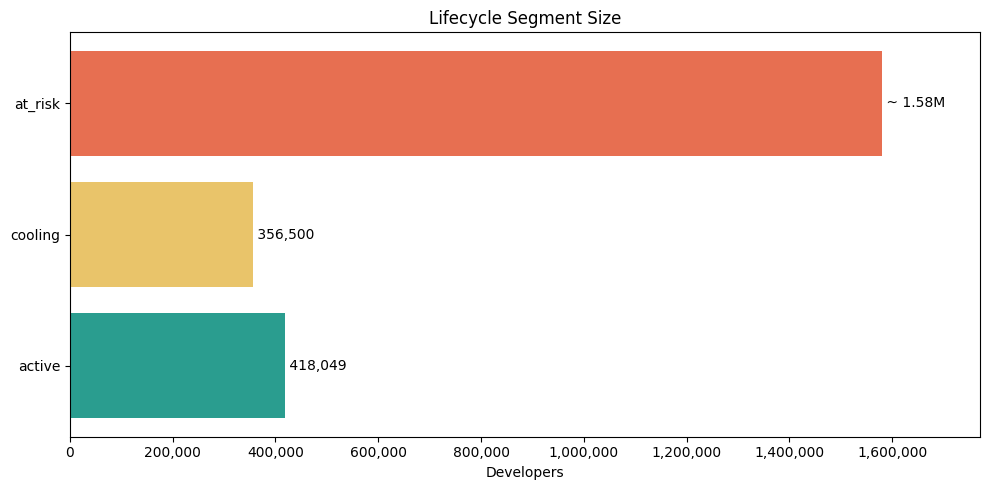

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = rollup_df.set_index('cluster_group').reindex(GROUP_ORDER).reset_index()
bars = ax.barh(plot_df['cluster_group'], plot_df['developers'], color=['#2a9d8f', '#e9c46a', '#e76f51'])
ax.set_title('Lifecycle Segment Size')
ax.set_xlabel('Developers')
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
max_val = plot_df['developers'].max()
ax.set_xlim(0, max_val * 1.12)
for bar, value, group in zip(bars, plot_df['developers'], plot_df['cluster_group']):
    label = ' ~ 1.58M' if group == 'at_risk' else f' {value:,.0f}'
    ax.text(value, bar.get_y() + bar.get_height() / 2, label, va='center', ha='left')
plt.tight_layout()
plt.show()

## 2. Persona Mix by Lifecycle Group

What this shows:
- the persona composition of `active`, `cooling`, and `at_risk`

Why it matters:
- it explains who dominates each lifecycle segment

What the presenter should say:
- `active` is more `GenAI`-heavy, `cooling` is more mixed, and `at_risk` carries a stronger `CUDA` share while still retaining a large `GenAI` component

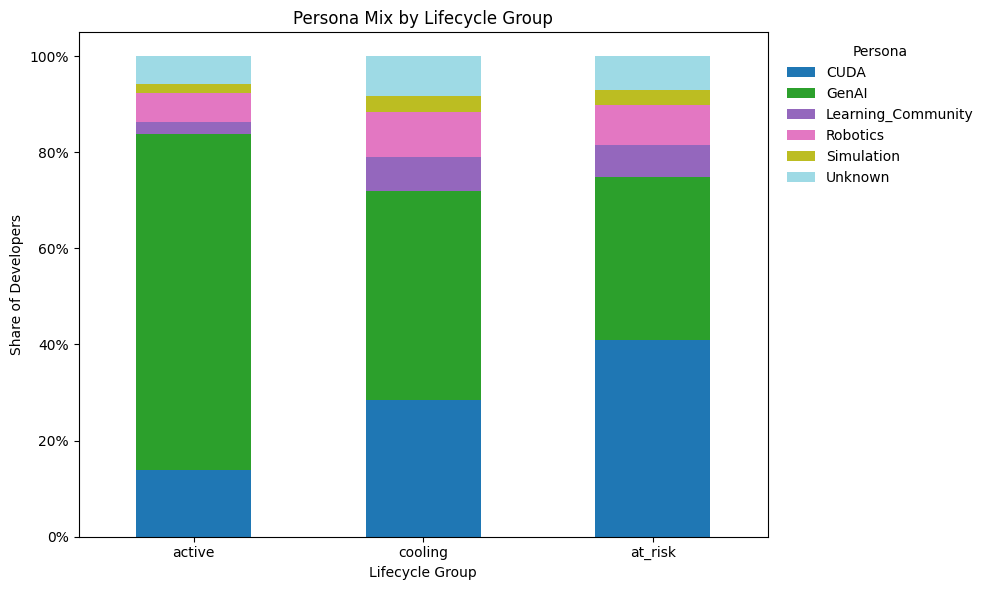

In [59]:
persona_mix_df = persona_mix_df.copy()
persona_mix_df['share'] = pd.to_numeric(persona_mix_df['share'], errors='coerce')
persona_mix_df = persona_mix_df.dropna(subset=['persona', 'share'])

if persona_mix_df.empty:
    persona_rows = []
    for _, row in composition_df.iterrows():
        known_share = 0.0
        for idx in [1, 2, 3]:
            persona = row.get(f'top_persona_{idx}')
            share = row.get(f'top_persona_{idx}_share')
            if pd.notna(persona) and pd.notna(share):
                share = float(share)
                known_share += share
                persona_rows.append({'cluster_group': row['cluster_group'], 'persona': persona, 'share': share})
        other_share = max(0.0, 1.0 - known_share)
        if other_share > 0:
            persona_rows.append({'cluster_group': row['cluster_group'], 'persona': 'Other', 'share': other_share})
    persona_mix_df = pd.DataFrame(persona_rows)

persona_order = sorted(persona_mix_df['persona'].dropna().astype(str).unique().tolist())
persona_pivot = persona_mix_df.set_index(['cluster_group', 'persona'])['share'].unstack(fill_value=0.0)
persona_pivot = persona_pivot.reindex(index=GROUP_ORDER, fill_value=0.0)
persona_pivot = persona_pivot.reindex(columns=persona_order, fill_value=0.0).astype('float64')

if persona_pivot.empty or persona_pivot.shape[1] == 0:
    raise ValueError('Persona mix is empty after preprocessing; check persona source data.')

fig, ax = plt.subplots(figsize=(10, 6))
persona_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Persona Mix by Lifecycle Group')
ax.set_xlabel('Lifecycle Group')
ax.set_ylabel('Share of Developers')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False, title='Persona')
plt.tight_layout()
plt.show()

## 3. Effort Mix by Lifecycle Group

What this shows:
- the effort-level composition of the three lifecycle groups

Why it matters:
- it shows depth differences without relying on unclear activity aggregates

What the presenter should say:
- `active` is more weighted toward the higher effort bands, `cooling` still retains visible high effort, and `at_risk` shifts relatively more toward lower effort

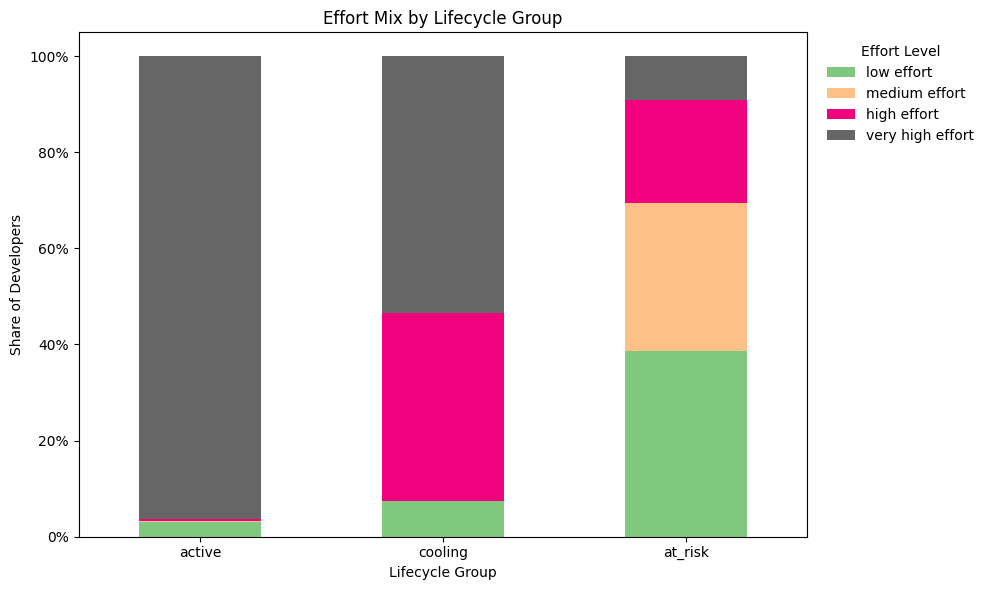

In [60]:
effort_order = ['low effort', 'medium effort', 'high effort', 'very high effort']
effort_mix_df = effort_mix_df.copy()
effort_mix_df['share'] = pd.to_numeric(effort_mix_df['share'], errors='coerce')
effort_mix_df = effort_mix_df.dropna(subset=['effort_level', 'share'])
effort_pivot = effort_mix_df.set_index(['cluster_group', 'effort_level'])['share'].unstack(fill_value=0.0)
effort_pivot = effort_pivot.reindex(index=GROUP_ORDER, fill_value=0.0)
effort_pivot = effort_pivot.reindex(columns=[c for c in effort_order if c in effort_pivot.columns], fill_value=0.0).astype('float64')

fig, ax = plt.subplots(figsize=(10, 6))
effort_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='Accent')
ax.set_title('Effort Mix by Lifecycle Group')
ax.set_xlabel('Lifecycle Group')
ax.set_ylabel('Share of Developers')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False, title='Effort Level')
plt.tight_layout()
plt.show()

## 4. API Usage Share

What this shows:
- the percent of developers in each lifecycle group with any API usage

Why it matters:
- it is the clearest current technical engagement signal in this presentation set

What the presenter should say:
- `active` developers are much more likely to have API usage than `cooling` or `at_risk`

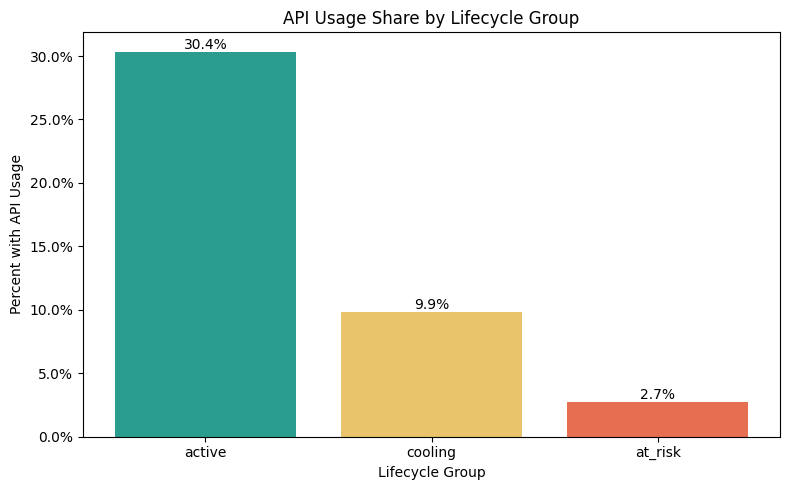

In [61]:
api_plot = api_df.set_index('cluster_group').reindex(GROUP_ORDER).reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(api_plot['cluster_group'], api_plot['pct_api_usage'], color=['#2a9d8f', '#e9c46a', '#e76f51'])
ax.set_title('API Usage Share by Lifecycle Group')
ax.set_xlabel('Lifecycle Group')
ax.set_ylabel('Percent with API Usage')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
for bar, value in zip(bars, api_plot['pct_api_usage']):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1%}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 5. Average API Count

What this shows:
- the average API count by lifecycle group

Why it matters:
- it shows API depth, not just whether any API usage exists

What the presenter should say:
- `active` has the highest API depth, `cooling` is much lower, and `at_risk` is very low

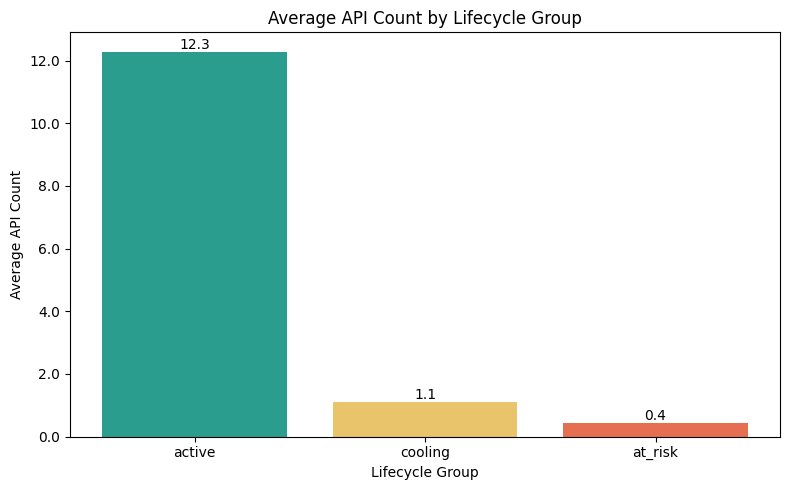

In [62]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(api_plot['cluster_group'], api_plot['avg_api_count'], color=['#2a9d8f', '#e9c46a', '#e76f51'])
ax.set_title('Average API Count by Lifecycle Group')
ax.set_xlabel('Lifecycle Group')
ax.set_ylabel('Average API Count')
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.1f}'))
for bar, value in zip(bars, api_plot['avg_api_count']):
    ax.text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 6. API Engagement Summary

What this shows:
- API usage share and API depth side by side

Why it matters:
- it makes the API story easy to present in one slide

What the presenter should say:
- `active` is not only more likely to have API usage; it also has higher API depth

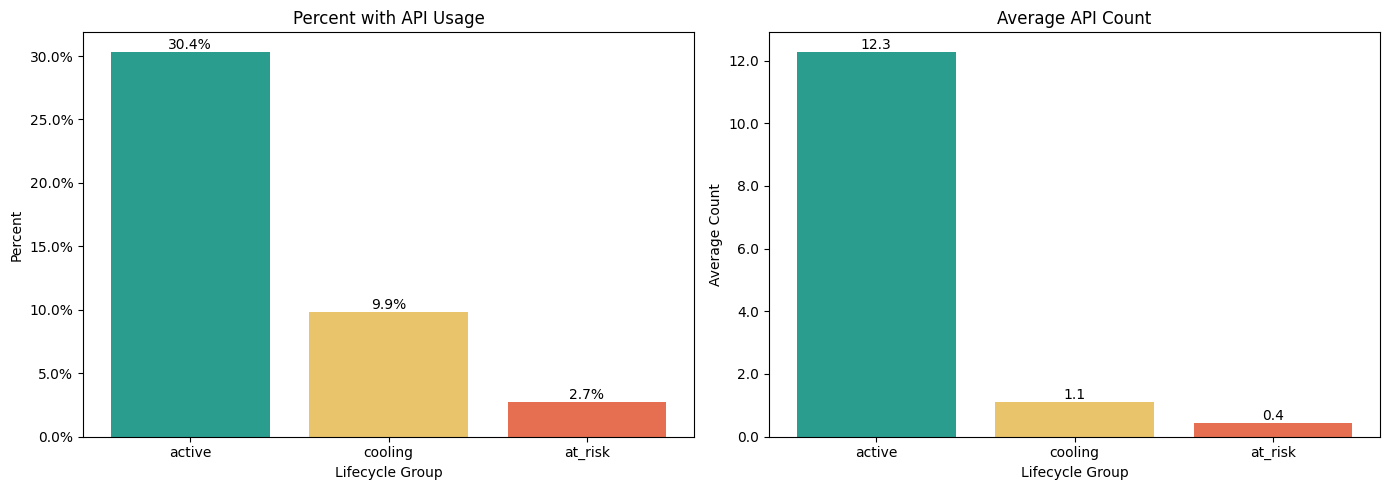

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(api_plot['cluster_group'], api_plot['pct_api_usage'], color=['#2a9d8f', '#e9c46a', '#e76f51'])
axes[0].set_title('Percent with API Usage')
axes[0].set_xlabel('Lifecycle Group')
axes[0].set_ylabel('Percent')
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
for bar, value in zip(bars1, api_plot['pct_api_usage']):
    axes[0].text(bar.get_x() + bar.get_width() / 2, value, f'{value:.1%}', ha='center', va='bottom')

bars2 = axes[1].bar(api_plot['cluster_group'], api_plot['avg_api_count'], color=['#2a9d8f', '#e9c46a', '#e76f51'])
axes[1].set_title('Average API Count')
axes[1].set_xlabel('Lifecycle Group')
axes[1].set_ylabel('Average Count')
axes[1].yaxis.set_major_formatter(StrMethodFormatter('{x:,.1f}'))
for bar, value in zip(bars2, api_plot['avg_api_count']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, value, f'{value:,.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 7. Activity Exposure by Lifecycle Group

What this shows:
- the share of developers in each lifecycle group who touched each activity

Why it matters:
- it shows which activities are visibly associated with each segment

What the presenter should say:
- `cooling` and `at_risk` are more visibly education- and download-led, while `active` is less uniformly defined by those broad activity types

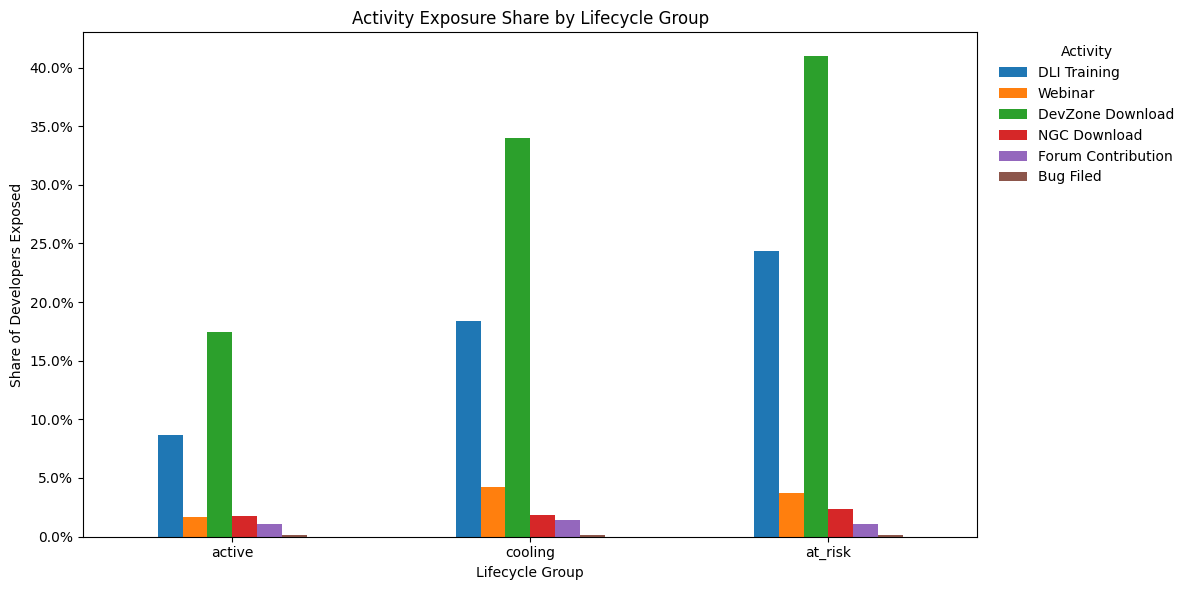

In [64]:
asset_specs = [
    ('dli_training', 'DLI Training', 'pct_dli_training', 'lift_dli_training'),
    ('webinar', 'Webinar', 'pct_webinar', 'lift_webinar'),
    ('devzone_download', 'DevZone Download', 'pct_devzone_download', 'lift_devzone_download'),
    ('ngc_download', 'NGC Download', 'pct_ngc_download', 'lift_ngc_download'),
    ('forum_contribution', 'Forum Contribution', 'pct_forum_contribution', 'lift_forum_contribution'),
    ('bug_filed', 'Bug Filed', 'pct_bug_filed', 'lift_bug_filed'),
    ('hackathon', 'Hackathon', 'pct_hackathon', 'lift_hackathon'),
]

available_assets = []
for asset_key, label, pct_col, lift_col in asset_specs:
    if pct_col in asset_profile_df.columns and lift_col in asset_profile_df.columns:
        max_pct = asset_profile_df[pct_col].fillna(0).max()
        if asset_key != 'hackathon' or max_pct >= 0.001:
            available_assets.append((asset_key, label, pct_col, lift_col))

any_exposure_df = con.execute(f"""
SELECT
    {cluster_group_case} AS cluster_group,
    AVG(CASE
        WHEN COALESCE(lifetime_dli_training_count, 0) > 0
          OR COALESCE(lifetime_webinar_count, 0) > 0
          OR COALESCE(lifetime_devzone_download_count, 0) > 0
          OR COALESCE(lifetime_ngc_download_count, 0) > 0
          OR COALESCE(lifetime_forum_count, 0) > 0
          OR COALESCE(lifetime_bug_count, 0) > 0
          OR COALESCE(lifetime_hackathon_count, 0) > 0
        THEN 1.0 ELSE 0.0 END
    ) AS pct_any_asset_exposed
FROM {CLUSTER_PROFILE_TABLE}
WHERE {cluster_group_case} IS NOT NULL
GROUP BY 1
""").fetchdf()
any_exposure_rate = any_exposure_df.set_index('cluster_group')['pct_any_asset_exposed'].reindex(GROUP_ORDER)

exposure_plot = asset_profile_df[['cluster_group'] + [pct_col for _, _, pct_col, _ in available_assets]].copy().set_index('cluster_group').reindex(GROUP_ORDER)
exposure_plot.columns = [label for _, label, _, _ in available_assets]

fig, ax = plt.subplots(figsize=(12, 6))
exposure_plot.plot(kind='bar', ax=ax)
ax.set_title('Activity Exposure Share by Lifecycle Group')
ax.set_xlabel('Lifecycle Group')
ax.set_ylabel('Share of Developers Exposed')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.tick_params(axis='x', rotation=0)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), frameon=False, title='Activity')
plt.tight_layout()
plt.show()

## 8. Activity Lift by Lifecycle Group

What this shows:
- which activities are over- or under-represented in each lifecycle group relative to the overall baseline

Why it matters:
- it separates broad common activities from activities that are disproportionately concentrated in one segment

What the presenter should say:
- DLI and webinar are more concentrated in `cooling` and `at_risk`, while smaller technical signals like forum, NGC, or bugs may carry more specialized meaning even at lower reach

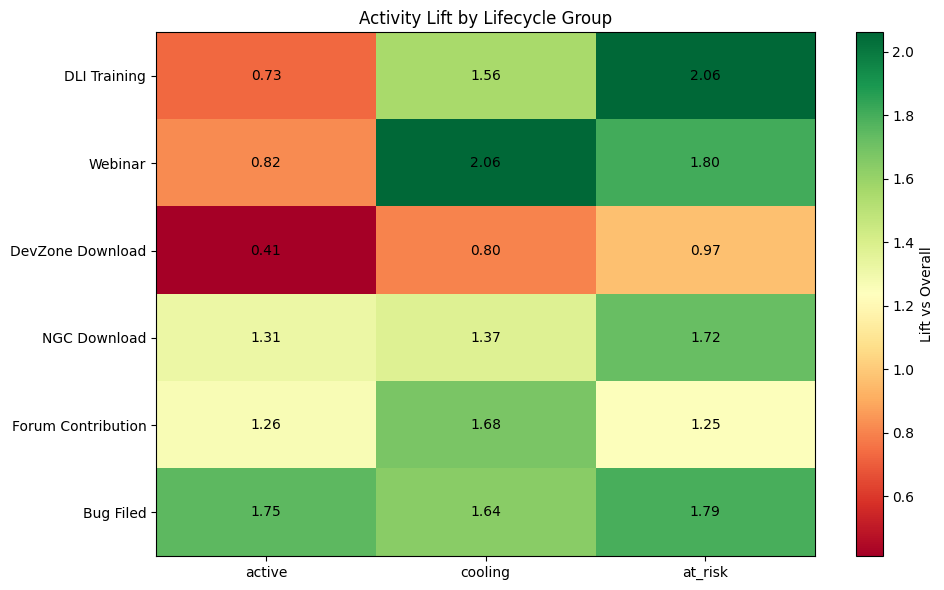

In [65]:
lift_plot = asset_profile_df[['cluster_group'] + [lift_col for _, _, _, lift_col in available_assets]].copy().set_index('cluster_group').reindex(GROUP_ORDER)
lift_plot.columns = [label for _, label, _, _ in available_assets]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(lift_plot.T.values, aspect='auto', cmap='RdYlGn', vmin=min(0.5, float(lift_plot.min().min())), vmax=max(2.0, float(lift_plot.max().max())))
ax.set_title('Activity Lift by Lifecycle Group')
ax.set_xticks(range(len(GROUP_ORDER)))
ax.set_xticklabels(GROUP_ORDER)
ax.set_yticks(range(len(lift_plot.columns)))
ax.set_yticklabels(lift_plot.columns)
for i in range(lift_plot.shape[1]):
    for j in range(lift_plot.shape[0]):
        value = lift_plot.iloc[j, i]
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color='black')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Lift vs Overall')
plt.tight_layout()
plt.show()

## 9. Most Distinctive Activities by Segment

What this shows:
- the top three activities in each lifecycle segment ranked by lift versus the overall developer baseline

Why it matters:
- it focuses the audience on what is distinctive about each segment rather than on broad activities that are common everywhere

What the presenter should say:
- `cooling` and `at_risk` are more concentrated in broad education and download touchpoints, while `active` is less defined by those broad activities and should be interpreted alongside API usage and effort depth


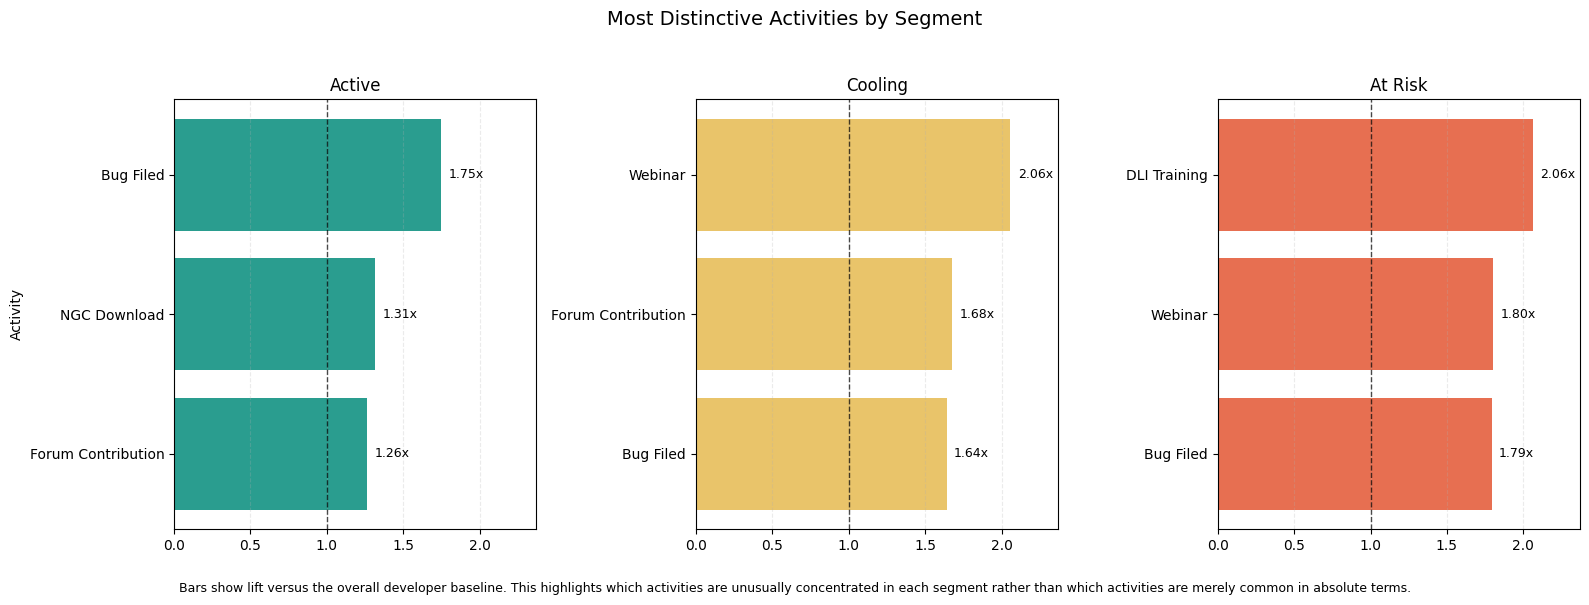

In [66]:
distinctive_rows = []
for group in GROUP_ORDER:
    group_row = asset_profile_df[asset_profile_df['cluster_group'] == group].iloc[0]
    for _, label, pct_col, lift_col in available_assets:
        distinctive_rows.append({
            'cluster_group': group,
            'asset': label,
            'exposure_share': float(group_row[pct_col]),
            'lift': float(group_row[lift_col]),
        })

distinctive_df = pd.DataFrame(distinctive_rows)

fig, axes = plt.subplots(1, len(GROUP_ORDER), figsize=(16, 6), sharex=True)
segment_colors = {'active': '#2a9d8f', 'cooling': '#e9c46a', 'at_risk': '#e76f51'}
xmax = max(1.25, float(distinctive_df['lift'].max()) * 1.15)

for ax, group in zip(axes, GROUP_ORDER):
    segment_df = distinctive_df[distinctive_df['cluster_group'] == group].nlargest(3, 'lift').sort_values('lift', ascending=True)
    ax.barh(segment_df['asset'], segment_df['lift'], color=segment_colors[group])
    ax.set_title(group.replace('_', ' ').title())
    ax.set_xlim(0, xmax)
    ax.axvline(1.0, color='black', linewidth=1, linestyle='--', alpha=0.7)
    ax.grid(axis='x', linestyle='--', alpha=0.25)
    for _, row in segment_df.iterrows():
        ax.text(row['lift'] + xmax * 0.02, row['asset'], f"{row['lift']:.2f}x", va='center', ha='left', fontsize=9)

axes[0].set_ylabel('Activity')
for ax in axes[1:]:
    ax.set_ylabel('')

fig.suptitle('Most Distinctive Activities by Segment', fontsize=14)
fig.text(
    0.5, 0.01,
    'Bars show lift versus the overall developer baseline. This highlights which activities are unusually concentrated in each segment rather than which activities are merely common in absolute terms.',
    ha='center', fontsize=9
)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


In [67]:
con.close()